In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-10.3.

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
import shutil
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

import random
import cv2
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
df = pd.read_csv('/kaggle/input/car-object-detection/data/train_solution_bounding_boxes (1).csv')

In [4]:
df['image_id'] = df['image'].apply(lambda x: x.split('.')[0])
df['classes'] = 0 

In [5]:
img_h, img_w = 380, 676
images_folder = '/kaggle/input/car-object-detection/data/training_images'

In [6]:
df['x_center'] = (df['xmin'] + df['xmax']) / 2 / img_w
df['y_center'] = (df['ymin'] + df['ymax']) / 2 / img_h
df['w'] = (df['xmax'] - df['xmin']) / img_w
df['h'] = (df['ymax'] - df['ymin']) / img_h

In [7]:
annotations_folder = '/kaggle/working/annotations/'
os.makedirs(annotations_folder, exist_ok=True)

In [8]:
for image_file, group in df.groupby('image'):
    label_file = os.path.join(annotations_folder, f"{os.path.splitext(image_file)[0]}.txt")
    with open(label_file, 'w') as f:
        for _, row in group.iterrows():
            f.write(f"{int(row['classes'])} {row['x_center']} {row['y_center']} {row['w']} {row['h']}\n")

In [9]:
images = df['image'].unique()
train_images, val_images = train_test_split(images, test_size=0.2, random_state=42)

In [10]:
base_dir = '/kaggle/working/datasets'
train_images_folder = os.path.join(base_dir, 'images/train')
val_images_folder = os.path.join(base_dir, 'images/val')
train_labels_folder = os.path.join(base_dir, 'labels/train')
val_labels_folder = os.path.join(base_dir, 'labels/val')

In [11]:
for folder in [train_images_folder, val_images_folder, train_labels_folder, val_labels_folder]:
    os.makedirs(folder, exist_ok=True)

In [12]:
def copy_files(images_list, img_src, label_src, img_dst, label_dst):
    for img_name in images_list:
        img_path = os.path.join(img_src, img_name)
        label_path = os.path.join(label_src, f"{os.path.splitext(img_name)[0]}.txt")

        shutil.copy2(img_path, img_dst)
        shutil.copy2(label_path, label_dst)

copy_files(train_images, images_folder, annotations_folder, train_images_folder, train_labels_folder)
copy_files(val_images, images_folder, annotations_folder, val_images_folder, val_labels_folder)

In [13]:
data_yaml = f"""
path: {base_dir}
train: images/train
val: images/val
nc: 1
names: ['object']
"""

with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(data_yaml)

In [14]:
model = YOLO('yolov8n.pt') 

model.train(
    data='/kaggle/working/data.yaml',
    epochs=50,
    batch=16,
    imgsz=676,
    workers=2,
    project='runs',
    name='custom_yolov8',
    verbose=True
)

100%|██████████| 6.25M/6.25M [00:00<00:00, 83.9MB/s]


Ultralytics 8.3.121 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=676, save=True, save_period=-1, cache=False, device=None, workers=2, project=runs, name=custom_yolov8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line

100%|██████████| 755k/755k [00:00<00:00, 16.7MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 73.8MB/s]


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  5.55it/s]


                   all         71        119      0.988      0.958      0.986      0.687


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.1ms preprocess, 1.7ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/custom_yolov8


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e4b6f487150>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [15]:
metrics = model.val()

Ultralytics 8.3.121 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2106.8±801.1 MB/s, size: 102.9 KB)


val: Scanning /kaggle/working/datasets/labels/val.cache... 71 images, 0 backgrounds, 0 corrupt: 100%|██████████| 71/71 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  3.94it/s]


                   all         71        119      0.988      0.958      0.986      0.684


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 2.9ms preprocess, 3.6ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs/custom_yolov82


In [16]:
def test_prediction(test_path):
    image_files = [os.path.join(test_path, file) for file in os.listdir(test_path)]
    coordinates = []
    
    for img_path in image_files:
        results = model(img_path)

        for result in results:
            for detection in result.boxes:
                x_min, y_min, x_max, y_max = detection.xyxy[0]
                name = img_path.split('/')[-1]
                coordinates.append({
                    'image': name,
                    'bounds': [x_min, y_min, x_max, y_max]
                })
    output = pd.DataFrame(coordinates)
    output.to_csv('submission.csv', index=False)

In [17]:
test_prediction(test_path ='/kaggle/input/car-object-detection/data/testing_images/')


image 1/1 /kaggle/input/car-object-detection/data/testing_images/vid_5_26420.jpg: 416x704 (no detections), 34.6ms
Speed: 2.0ms preprocess, 34.6ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 704)

image 1/1 /kaggle/input/car-object-detection/data/testing_images/vid_5_31520.jpg: 416x704 (no detections), 6.4ms
Speed: 1.7ms preprocess, 6.4ms inference, 0.7ms postprocess per image at shape (1, 3, 416, 704)

image 1/1 /kaggle/input/car-object-detection/data/testing_images/vid_5_29420.jpg: 416x704 2 objects, 6.4ms
Speed: 1.6ms preprocess, 6.4ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 704)

image 1/1 /kaggle/input/car-object-detection/data/testing_images/vid_5_31720.jpg: 416x704 1 object, 6.4ms
Speed: 1.6ms preprocess, 6.4ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 704)

image 1/1 /kaggle/input/car-object-detection/data/testing_images/vid_5_26560.jpg: 416x704 1 object, 6.4ms
Speed: 1.6ms preprocess, 6.4ms inference, 1.3ms postprocess per 


image 1/1 /kaggle/input/car-object-detection/data/testing_images/vid_5_26800.jpg: 416x704 3 objects, 6.5ms
Speed: 1.8ms preprocess, 6.5ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 704)


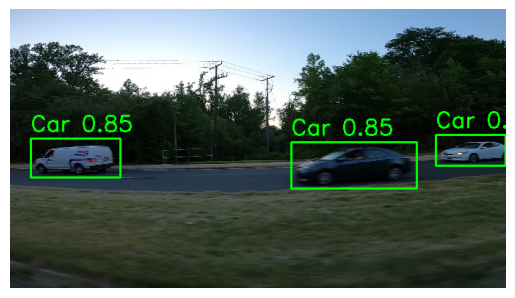

In [18]:
image_path = '/kaggle/input/car-object-detection/data/testing_images/vid_5_26800.jpg'
results = model(image_path)
image = cv2.imread(image_path)
for result in results:
    for detection in result.boxes:
        x_min, y_min, x_max, y_max = detection.xyxy[0]
        confidence = round(float(detection.conf[0]), 2)
        class_id = int(detection.cls[0])
        cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)
        label = f"Car {confidence}"
        cv2.putText(image, label, (int(x_min), int(y_min)-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()


image 1/1 /kaggle/input/car-object-detection/data/testing_images/vid_5_26640.jpg: 416x704 4 objects, 6.6ms
Speed: 2.3ms preprocess, 6.6ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 704)


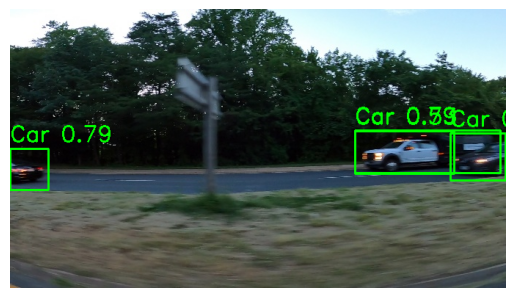

In [19]:
image_path = '/kaggle/input/car-object-detection/data/testing_images/vid_5_26640.jpg'
results = model(image_path)
image = cv2.imread(image_path)
for result in results:
    for detection in result.boxes:
        x_min, y_min, x_max, y_max = detection.xyxy[0]
        confidence = round(float(detection.conf[0]), 2)
        class_id = int(detection.cls[0])
        cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)
        label = f"Car {confidence}"
        cv2.putText(image, label, (int(x_min), int(y_min)-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()